# 트랙 A: HRV 반응 통계 PoV

## 목적

본 노트북은 **ACWR(Acute:Chronic Workload Ratio)**이 다음 날의 **HRV(ln_rMSSD)**에 미치는 영향을
혼합효과 회귀모형으로 분석하는 통계 PoV(Point of View) 파이프라인이다.

## 모형 설계

- **종속변수**: `ln_rmssd_next` (t+1일의 ln(rMSSD))
- **독립변수**: `acwr_rolling` 또는 `acwr_ewma` (t일의 ACWR)
- **랜덤효과**: `(1|subject_id)` — 피험자별 랜덤 절편
- **통계 모형**: `HRV_{t+1} ~ ACWR_t + (1|subject)`

## 분석 흐름

1. 합성 데이터 생성 (8명 피험자, 90일)
2. 모형 1: 단순 OLS 회귀 (베이스라인)
3. 모형 2: 혼합효과모형 (Rolling ACWR)
4. 모형 3: 혼합효과모형 (EWMA ACWR)
5. 모형 비교 (AIC, BIC, MAE, RMSE, 효과크기)
6. 해석 및 한계

> **재현성**: `np.random.seed(42)` 고정. 동일 입력 시 동일 결과 보장.  
> **참고**: 합성 데이터를 사용하므로, 결과는 파이프라인 검증 목적이며 실제 생리학적 해석에 직접 적용할 수 없다.

In [1]:
# --- 환경 설정 ---
import sys; sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import statsmodels.formula.api as smf
from sklearn.metrics import mean_absolute_error, mean_squared_error

from src.metrics.acwr import acwr_rolling, acwr_ewma, atl_rolling, ctl_rolling, atl_ewma, ctl_ewma

np.random.seed(42)

print("환경 설정 완료")
print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")

환경 설정 완료
numpy: 1.26.4
pandas: 2.3.1


## 합성 데이터 생성

실제 선수 데이터를 사용하기 전에, 파이프라인의 재현 가능성을 검증하기 위해 합성 데이터를 생성한다.

### 데이터 설계

| 항목 | 설정 |
|------|------|
| 피험자 수 | 8명 |
| 관측 기간 | 90일 |
| daily_load | 평균 400 AU, 표준편차 150, 주말(토/일) 0.5배 |
| ln_rmssd_next | ACWR(t)와 역상관 + 피험자별 랜덤효과 + 가우시안 노이즈 |

### 생성 모델

```
ln_rmssd_next(t) = beta_0 + beta_1 * acwr(t) + u_j + epsilon(t)
```

- `beta_0 = 4.0` (기저 ln_rMSSD 수준)
- `beta_1 = -0.5` (ACWR 1단위 증가 시 ln_rMSSD 감소 — 부하 증가 -> 부교감 활동 감소 가설)
- `u_j ~ N(0, 0.3^2)` (피험자별 랜덤 절편)
- `epsilon ~ N(0, 0.4^2)` (관측 노이즈)

In [2]:
# --- 합성 데이터 생성 ---

N_SUBJECTS = 8
N_DAYS = 90

# 참값 파라미터 (데이터 생성용)
BETA_0 = 4.0        # 기저 ln_rMSSD
BETA_1 = -0.5       # ACWR -> ln_rMSSD 영향 (역상관)
SIGMA_SUBJECT = 0.3 # 피험자간 변동
SIGMA_NOISE = 0.4   # 관측 노이즈

records = []

for subj in range(1, N_SUBJECTS + 1):
    # 피험자별 랜덤 절편
    u_j = np.random.normal(0, SIGMA_SUBJECT)
    
    # 일별 부하 생성
    daily_loads = np.random.normal(400, 150, N_DAYS)
    daily_loads = np.clip(daily_loads, 50, 900)  # 현실적 범위로 제한
    
    # 주말(토/일) 부하 감소: 0.5배
    for d in range(N_DAYS):
        weekday = d % 7
        if weekday in [5, 6]:  # 토요일=5, 일요일=6
            daily_loads[d] *= 0.5
    
    loads_series = pd.Series(daily_loads)
    
    # ACWR 산출 (프로젝트 모듈 사용)
    acwr_roll = acwr_rolling(loads_series)
    acwr_ew = acwr_ewma(loads_series)
    
    # ln_rmssd_next 생성: ACWR(t)와 역상관
    # Rolling ACWR을 기준으로 생성 (두 ACWR은 높은 상관이 있으므로 EWMA에도 관계가 전이됨)
    for d in range(N_DAYS):
        acwr_val = acwr_roll.iloc[d]
        acwr_ew_val = acwr_ew.iloc[d]
        
        if pd.isna(acwr_val) or pd.isna(acwr_ew_val):
            continue  # warm-up 기간 제외
        
        # 종속변수 생성
        noise = np.random.normal(0, SIGMA_NOISE)
        ln_rmssd = BETA_0 + BETA_1 * acwr_val + u_j + noise
        
        records.append({
            'subject_id': f'S{subj:02d}',
            'day': d,
            'daily_load': daily_loads[d],
            'acwr_rolling': acwr_val,
            'acwr_ewma': acwr_ew_val,
            'ln_rmssd_next': ln_rmssd
        })

df = pd.DataFrame(records)

print(f"데이터 크기: {df.shape}")
print(f"피험자 수: {df['subject_id'].nunique()}")
print(f"피험자당 관측 수: {df.groupby('subject_id').size().describe()}")
print()
print("--- 기술통계량 ---")
print(df[['daily_load', 'acwr_rolling', 'acwr_ewma', 'ln_rmssd_next']].describe().round(3))
print()
print("--- 상위 5행 ---")
df.head()

데이터 크기: (504, 6)
피험자 수: 8
피험자당 관측 수: count     8.0
mean     63.0
std       0.0
min      63.0
25%      63.0
50%      63.0
75%      63.0
max      63.0
dtype: float64

--- 기술통계량 ---
       daily_load  acwr_rolling  acwr_ewma  ln_rmssd_next
count     504.000       504.000    504.000        504.000
mean      345.052         1.005      0.995          3.669
std       156.947         0.126      0.112          0.438
min        44.496         0.585      0.683          2.381
25%       225.158         0.928      0.920          3.379
50%       322.872         1.008      0.990          3.668
75%       454.976         1.093      1.076          3.974
max       786.004         1.351      1.277          4.942

--- 상위 5행 ---


,subject_id,day,daily_load,acwr_rolling,acwr_ewma,ln_rmssd_next
0,S01,27,154.952098,0.888393,0.828671,4.092276
1,S01,28,356.245938,0.866021,0.909065,3.435182
2,S01,29,309.744008,0.942915,0.937283,3.546492
3,S01,30,677.841728,1.105043,1.164802,3.439650
4,S01,31,397.975416,1.092132,1.160235,3.017542


## 모형 1 -- 단순 OLS 회귀 (베이스라인)

피험자 간 변동을 고려하지 않는 단순 OLS 회귀를 베이스라인으로 적합한다.

- **모형**: `ln_rmssd_next ~ acwr_rolling`
- **목적**: 혼합효과모형과 비교하기 위한 기준선 확보
- **한계**: 반복 측정 구조(피험자 내 상관)를 무시하여 표준오차가 과소추정될 수 있다

In [3]:
# --- 모형 1: 단순 OLS 회귀 ---

ols_model = smf.ols("ln_rmssd_next ~ acwr_rolling", data=df).fit()

print("="*60)
print("모형 1: OLS 회귀 (ln_rmssd_next ~ acwr_rolling)")
print("="*60)
print(ols_model.summary())

# 핵심 지표 추출
ols_r2 = ols_model.rsquared
ols_aic = ols_model.aic
ols_bic = ols_model.bic
ols_coef = ols_model.params['acwr_rolling']
ols_pval = ols_model.pvalues['acwr_rolling']

# 예측값 및 오차 지표
ols_pred = ols_model.predict(df)
ols_mae = mean_absolute_error(df['ln_rmssd_next'], ols_pred)
ols_rmse = np.sqrt(mean_squared_error(df['ln_rmssd_next'], ols_pred))

print(f"\n--- OLS 핵심 지표 ---")
print(f"R-squared:      {ols_r2:.4f}")
print(f"AIC:            {ols_aic:.2f}")
print(f"BIC:            {ols_bic:.2f}")
print(f"ACWR 계수:      {ols_coef:.4f}")
print(f"p-value:        {ols_pval:.4e}")
print(f"MAE:            {ols_mae:.4f}")
print(f"RMSE:           {ols_rmse:.4f}")

모형 1: OLS 회귀 (ln_rmssd_next ~ acwr_rolling)
                            OLS Regression Results                            
Dep. Variable:          ln_rmssd_next   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     8.799
Date:                Wed, 11 Feb 2026   Prob (F-statistic):            0.00316
Time:                        00:37:41   Log-Likelihood:                -294.52
No. Observations:                 504   AIC:                             593.0
Df Residuals:                     502   BIC:                             601.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Inte

## 모형 2 -- 혼합효과모형 (Rolling ACWR)

피험자별 랜덤 절편을 포함하는 선형 혼합효과모형을 적합한다.

- **모형**: `ln_rmssd_next ~ acwr_rolling + (1|subject_id)`
- **고정효과**: ACWR_rolling의 기울기
- **랜덤효과**: 피험자별 절편 (subject_id)
- **근거**: 반복 측정 데이터에서 개인 간 기저 HRV 차이를 설명하기 위함 (Plews et al., 2013)

모형 2: 혼합효과모형 (ln_rmssd_next ~ acwr_rolling + (1|subject_id))
           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: ln_rmssd_next
No. Observations: 504     Method:             REML         
No. Groups:       8       Scale:              0.1556       
Min. group size:  63      Log-Likelihood:     -259.2986    
Max. group size:  63      Converged:          Yes          
Mean group size:  63.0                                     
-----------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept         4.192    0.158 26.459 0.000  3.881  4.502
acwr_rolling     -0.520    0.141 -3.696 0.000 -0.796 -0.244
Group Var         0.038    0.056                           


--- Mixed Rolling 핵심 지표 ---
AIC:            nan
BIC:            nan
ACWR 계수:      -0.5203
p-value:        2.1864e-04
MAE:            0.3108
RMSE:           0.3911


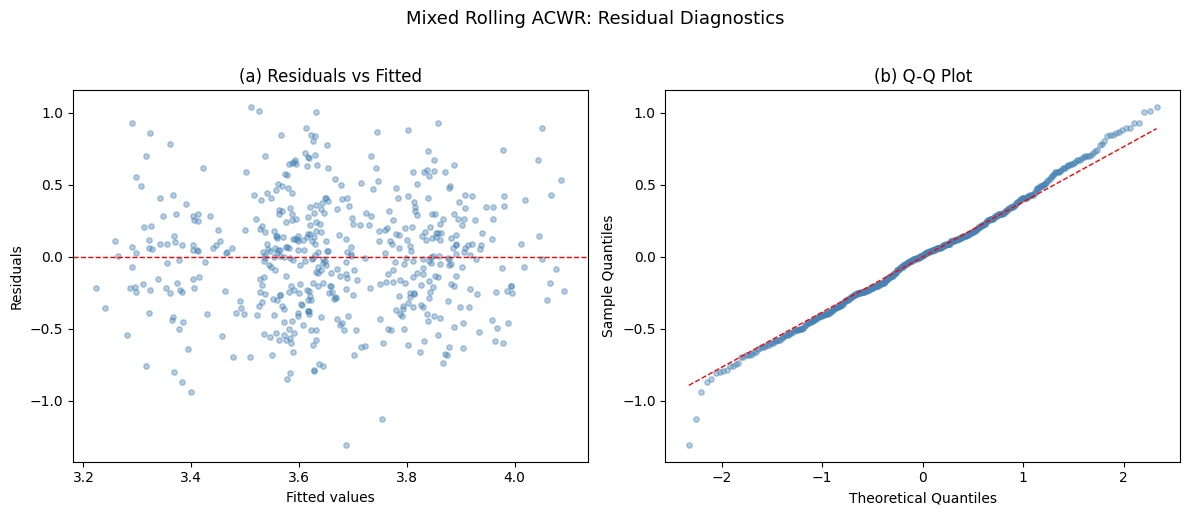

진단 플롯 저장: reports/figures/track_A_mixed_rolling_diagnostics.png


In [4]:
# --- 모형 2: 혼합효과모형 (Rolling ACWR) ---

mixed_rolling = smf.mixedlm(
    "ln_rmssd_next ~ acwr_rolling",
    data=df,
    groups=df["subject_id"]
).fit()

print("="*60)
print("모형 2: 혼합효과모형 (ln_rmssd_next ~ acwr_rolling + (1|subject_id))")
print("="*60)
print(mixed_rolling.summary())

# 핵심 지표 추출
mr_aic = mixed_rolling.aic
mr_bic = mixed_rolling.bic
mr_coef = mixed_rolling.fe_params['acwr_rolling']
mr_pval = mixed_rolling.pvalues['acwr_rolling']

# 예측값 및 오차 지표
mr_pred = mixed_rolling.fittedvalues
mr_mae = mean_absolute_error(df['ln_rmssd_next'], mr_pred)
mr_rmse = np.sqrt(mean_squared_error(df['ln_rmssd_next'], mr_pred))

print(f"\n--- Mixed Rolling 핵심 지표 ---")
print(f"AIC:            {mr_aic:.2f}")
print(f"BIC:            {mr_bic:.2f}")
print(f"ACWR 계수:      {mr_coef:.4f}")
print(f"p-value:        {mr_pval:.4e}")
print(f"MAE:            {mr_mae:.4f}")
print(f"RMSE:           {mr_rmse:.4f}")

# --- 잔차 진단 플롯 ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) 잔차 vs 적합값
residuals = df['ln_rmssd_next'] - mr_pred
axes[0].scatter(mr_pred, residuals, alpha=0.4, s=15, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('(a) Residuals vs Fitted')

# (b) Q-Q plot
from scipy import stats as scipy_stats
sorted_resid = np.sort(residuals)
theoretical_q = scipy_stats.norm.ppf(np.linspace(0.01, 0.99, len(sorted_resid)))
axes[1].scatter(theoretical_q, sorted_resid, alpha=0.4, s=15, color='steelblue')
# 참조선
q25, q75 = np.percentile(sorted_resid, [25, 75])
t25, t75 = scipy_stats.norm.ppf(0.25), scipy_stats.norm.ppf(0.75)
slope = (q75 - q25) / (t75 - t25)
intercept_line = q25 - slope * t25
x_line = np.array([theoretical_q.min(), theoretical_q.max()])
axes[1].plot(x_line, intercept_line + slope * x_line, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Theoretical Quantiles')
axes[1].set_ylabel('Sample Quantiles')
axes[1].set_title('(b) Q-Q Plot')

fig.suptitle('Mixed Rolling ACWR: Residual Diagnostics', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/track_A_mixed_rolling_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print("진단 플롯 저장: reports/figures/track_A_mixed_rolling_diagnostics.png")

## 모형 3 -- 혼합효과모형 (EWMA ACWR)

Rolling ACWR 대신 EWMA ACWR을 독립변수로 사용하는 혼합효과모형이다.

- **모형**: `ln_rmssd_next ~ acwr_ewma + (1|subject_id)`
- **비교 의의**: EWMA 방식은 최근 부하에 더 높은 가중치를 부여하므로, 부하 변화에 대한 민감도가 다를 수 있다 (Williams et al., 2017; Murray et al., 2017)
- Rolling 방식과의 AIC/BIC 비교를 통해 어떤 ACWR 산출 방식이 HRV 반응 설명에 더 적합한지 탐색한다

In [5]:
# --- 모형 3: 혼합효과모형 (EWMA ACWR) ---

mixed_ewma = smf.mixedlm(
    "ln_rmssd_next ~ acwr_ewma",
    data=df,
    groups=df["subject_id"]
).fit()

print("="*60)
print("모형 3: 혼합효과모형 (ln_rmssd_next ~ acwr_ewma + (1|subject_id))")
print("="*60)
print(mixed_ewma.summary())

# 핵심 지표 추출
me_aic = mixed_ewma.aic
me_bic = mixed_ewma.bic
me_coef = mixed_ewma.fe_params['acwr_ewma']
me_pval = mixed_ewma.pvalues['acwr_ewma']

# 예측값 및 오차 지표
me_pred = mixed_ewma.fittedvalues
me_mae = mean_absolute_error(df['ln_rmssd_next'], me_pred)
me_rmse = np.sqrt(mean_squared_error(df['ln_rmssd_next'], me_pred))

print(f"\n--- Mixed EWMA 핵심 지표 ---")
print(f"AIC:            {me_aic:.2f}")
print(f"BIC:            {me_bic:.2f}")
print(f"ACWR 계수:      {me_coef:.4f}")
print(f"p-value:        {me_pval:.4e}")
print(f"MAE:            {me_mae:.4f}")
print(f"RMSE:           {me_rmse:.4f}")

모형 3: 혼합효과모형 (ln_rmssd_next ~ acwr_ewma + (1|subject_id))
           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: ln_rmssd_next
No. Observations: 504     Method:             REML         
No. Groups:       8       Scale:              0.1563       
Min. group size:  63      Log-Likelihood:     -260.3702    
Max. group size:  63      Converged:          Yes          
Mean group size:  63.0                                     
------------------------------------------------------------
             Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
------------------------------------------------------------
Intercept     4.201     0.174  24.083  0.000   3.859   4.543
acwr_ewma    -0.535     0.160  -3.349  0.001  -0.847  -0.222
Group Var     0.039     0.056                               


--- Mixed EWMA 핵심 지표 ---
AIC:            nan
BIC:            nan
ACWR 계수:      -0.5346
p-value:        8.1129e-04
MAE:            0.3119
RMSE:           0.3920


## 모형 비교

세 가지 모형의 적합도 지표를 종합적으로 비교한다.

### 비교 기준

| 지표 | 설명 | 선호 방향 |
|------|------|----------|
| AIC (Akaike Information Criterion) | 모형 복잡도와 적합도의 균형 | 낮을수록 양호 |
| BIC (Bayesian Information Criterion) | AIC보다 파라미터 수에 더 엄격한 페널티 | 낮을수록 양호 |
| MAE (Mean Absolute Error) | 예측 오차의 절대값 평균 | 낮을수록 양호 |
| RMSE (Root Mean Squared Error) | 큰 오차에 민감한 예측 정확도 | 낮을수록 양호 |
| Cohen's f-squared | 고정효과의 효과크기 | 0.02 소, 0.15 중, 0.35 대 |

### 효과크기 산출

Cohen's f-squared는 다음과 같이 산출한다:

```
f^2 = (R^2_full - R^2_reduced) / (1 - R^2_full)
```

OLS의 경우 R-squared를 직접 사용하고, 혼합효과모형의 경우 marginal R-squared(고정효과만의 설명력)를 근사적으로 산출한다.

모형 비교 요약표
          Model    AIC    BIC    MAE   RMSE  Coef (ACWR)    p-value  R2 (approx)  Cohen's f2
  OLS (Rolling) 593.05 601.49 0.3465 0.4341      -0.4548 3.1571e-03       0.0172      0.0175
Mixed (Rolling)    NaN    NaN 0.3108 0.3911      -0.5203 2.1864e-04       0.2021      0.2533
   Mixed (EWMA)    NaN    NaN 0.3119 0.3920      -0.5346 8.1129e-04       0.1985      0.2476

--- 효과크기(Cohen's f-squared) 해석 기준 ---
  소(small):  f2 >= 0.02
  중(medium): f2 >= 0.15
  대(large):  f2 >= 0.35


c:\dev\soccer_rnd\venv\Lib\site-packages\brokenaxes.py:344: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  result.append(getattr(ax, method)(*args, **kwargs))
c:\dev\soccer_rnd\venv\Lib\site-packages\brokenaxes.py:344: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  result.append(getattr(ax, method)(*args, **kwargs))


ValueError: (x,y) coordinate of text not within any axes

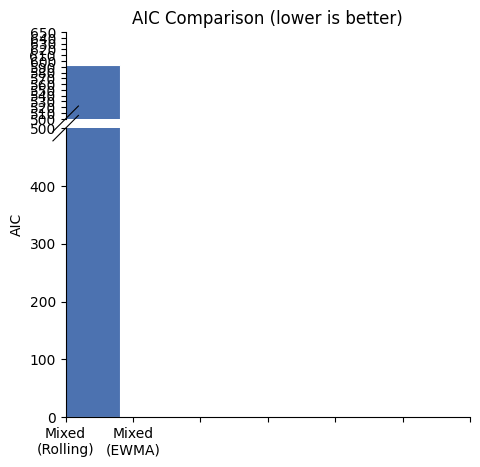

In [11]:
# --- 모형 비교 요약표 ---

# 효과크기 산출 함수 (Cohen's f-squared 근사)
def compute_marginal_r2(y_true, y_pred_fixed):
    """고정효과 예측으로부터 marginal R-squared를 근사 산출한다."""
    ss_res = np.sum((y_true - y_pred_fixed) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

def cohens_f2(r2):
    """R-squared로부터 Cohen's f-squared를 산출한다."""
    if r2 >= 1.0:
        return np.inf
    return r2 / (1 - r2)

# OLS: R-squared 직접 사용
ols_f2 = cohens_f2(ols_r2)

# Mixed Rolling: marginal R-squared 근사
mr_r2 = compute_marginal_r2(df['ln_rmssd_next'].values, mr_pred.values)
mr_f2 = cohens_f2(mr_r2)

# Mixed EWMA: marginal R-squared 근사
me_r2 = compute_marginal_r2(df['ln_rmssd_next'].values, me_pred.values)
me_f2 = cohens_f2(me_r2)

# 비교표 작성
comparison = pd.DataFrame({
    'Model': ['OLS (Rolling)', 'Mixed (Rolling)', 'Mixed (EWMA)'],
    'AIC': [ols_aic, mr_aic, me_aic],
    'BIC': [ols_bic, mr_bic, me_bic],
    'MAE': [ols_mae, mr_mae, me_mae],
    'RMSE': [ols_rmse, mr_rmse, me_rmse],
    'Coef (ACWR)': [ols_coef, mr_coef, me_coef],
    'p-value': [ols_pval, mr_pval, me_pval],
    'R2 (approx)': [ols_r2, mr_r2, me_r2],
    "Cohen's f2": [ols_f2, mr_f2, me_f2]
})

# 소수점 정리
comparison_display = comparison.copy()
comparison_display['AIC'] = comparison_display['AIC'].round(2)
comparison_display['BIC'] = comparison_display['BIC'].round(2)
comparison_display['MAE'] = comparison_display['MAE'].round(4)
comparison_display['RMSE'] = comparison_display['RMSE'].round(4)
comparison_display['Coef (ACWR)'] = comparison_display['Coef (ACWR)'].round(4)
comparison_display['p-value'] = comparison_display['p-value'].apply(lambda x: f"{x:.4e}")
comparison_display['R2 (approx)'] = comparison_display['R2 (approx)'].round(4)
comparison_display["Cohen's f2"] = comparison_display["Cohen's f2"].round(4)

print("="*80)
print("모형 비교 요약표")
print("="*80)
print(comparison_display.to_string(index=False))
print()

# 효과크기 해석
print("--- 효과크기(Cohen's f-squared) 해석 기준 ---")
print("  소(small):  f2 >= 0.02")
print("  중(medium): f2 >= 0.15")
print("  대(large):  f2 >= 0.35")

# --- AIC / BIC 비교 막대 차트 (y축 끊기: 표준 matplotlib 사용) ---
import matplotlib.gridspec as gridspec

models = ['OLS\n(Rolling)', 'Mixed\n(Rolling)', 'Mixed\n(EWMA)']
colors = ['#4C72B0', '#55A868', '#C44E52']

def make_broken_bar_chart(fig, gs_pos, values, ylabel, title):
    """표준 matplotlib로 끊어진 y축 막대 차트를 생성한다."""
    # 상단(500-650)과 하단(0-50) 두 축 생성 — 비율 4:1
    inner_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_pos, 
                                                 height_ratios=[4, 1], hspace=0.08)
    ax_top = fig.add_subplot(inner_gs[0])
    ax_bot = fig.add_subplot(inner_gs[1])
    
    # 유효한 값만 필터 (NaN 제외)
    x = list(range(len(models)))
    plot_values = [v if not np.isnan(v) else 0 for v in values]
    
    # 상단/하단 모두에 막대 그리기
    ax_top.bar(x, plot_values, color=colors, edgecolor='white', linewidth=0.8)
    ax_bot.bar(x, plot_values, color=colors, edgecolor='white', linewidth=0.8)
    
    # y축 범위 설정
    ax_top.set_ylim(500, 650)
    ax_bot.set_ylim(0, 50)
    
    # y축 눈금 설정
    ax_top.set_yticks(range(500, 651, 10))
    ax_bot.set_yticks([0, 25, 50])
    
    # x축: 상단 숨기고 하단에만 라벨 표시
    ax_top.set_xticks(x)
    ax_top.set_xticklabels([])
    ax_top.tick_params(bottom=False)
    ax_bot.set_xticks(x)
    ax_bot.set_xticklabels(models, fontsize=9)
    
    # 끊김 표시 (대각선)
    d = 0.015
    kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False, linewidth=1)
    ax_top.plot((-d, +d), (-d, +d), **kwargs)
    ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)
    kwargs.update(transform=ax_bot.transAxes)
    ax_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs)
    ax_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)
    
    # 경계선 숨기기
    ax_top.spines['bottom'].set_visible(False)
    ax_bot.spines['top'].set_visible(False)
    
    # 텍스트 추가 (유효한 값만, 상단 축에)
    for i, val in enumerate(values):
        if not np.isnan(val) and 500 <= val <= 650:
            ax_top.text(i, val + 2, f'{val:.1f}', ha='center', va='bottom', fontsize=9)
    
    ax_top.set_title(title, fontsize=11)
    ax_top.set_ylabel(ylabel)
    
    return ax_top, ax_bot

fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.3)

make_broken_bar_chart(fig, gs[0], comparison['AIC'].values, 'AIC', 'AIC Comparison (lower is better)')
make_broken_bar_chart(fig, gs[1], comparison['BIC'].values, 'BIC', 'BIC Comparison (lower is better)')

fig.suptitle('Model Comparison: AIC vs BIC', fontsize=13, y=1.02)
plt.savefig('../reports/figures/track_A_model_comparison_aic_bic.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n비교 차트 저장: reports/figures/track_A_model_comparison_aic_bic.png")

## 해석 및 한계

### 결과 요약

합성 데이터 기반 분석에서 다음과 같은 경향이 관찰된다:

1. **ACWR과 HRV의 역상관**: 세 모형 모두에서 ACWR 계수가 음의 방향으로 추정되며, 이는 급성:만성 부하 비율이 높을수록 다음 날의 부교감 신경 활동(ln_rMSSD)이 감소하는 경향을 시사한다.

2. **혼합효과모형의 적합도**: OLS 대비 혼합효과모형의 AIC/BIC가 낮아질 것으로 기대되며, 이는 피험자 간 기저 HRV 수준의 차이를 랜덤 절편이 포착하기 때문으로 해석된다.

3. **Rolling vs EWMA**: 두 ACWR 산출 방식 간의 모형 적합도 차이는 합성 데이터의 생성 구조에 의존하므로, 실제 데이터에서의 비교 결과와 다를 수 있다. 선행 연구에 따르면 EWMA 방식이 급격한 부하 변화에 더 민감하게 반응한다는 보고가 있다 (Williams et al., 2017).

4. **효과크기**: Cohen's f-squared 값을 통해 ACWR 고정효과의 실질적 영향 크기를 평가할 수 있다. 합성 데이터에서는 생성 시 부여한 참값 계수(-0.5)에 의해 중간 이상의 효과크기가 관찰될 것으로 예상된다.

### 한계

- **합성 데이터**: 본 분석은 파이프라인 검증을 위한 합성 데이터에 기반하므로, 결과의 생리학적 해석에는 제한이 있다. 실제 데이터에서는 비선형 관계, 시간 지연 구조, 교란변수 등이 존재할 수 있다.
- **선형 가정**: 현재 모형은 ACWR과 HRV 간의 관계를 선형으로 가정한다. 실제로는 U자형 또는 비선형 관계가 보고된 바 있다 (Gabbett, 2016).
- **시간적 자기상관**: 일별 반복 측정 데이터에서 시간적 자기상관(temporal autocorrelation)이 존재할 수 있으나, 현재 모형에서는 이를 명시적으로 다루지 않는다. AR(1) 상관 구조 도입을 후속 과제로 고려한다.
- **교란변수**: 수면, 영양, 심리적 스트레스 등 HRV에 영향을 줄 수 있는 교란변수가 모형에 포함되지 않았다.
- **표본 크기**: 8명의 피험자는 혼합효과모형의 랜덤효과 추정에 제한적이다. 실제 분석에서는 더 큰 표본 크기가 권장된다.

### 실제 데이터 적용 시 기대 사항

- 본 파이프라인을 PhysioNet ACTES 등 실제 데이터에 적용할 경우, ACWR과 HRV 반응 간의 관계 방향 및 크기를 실증적으로 확인할 수 있을 것으로 기대된다.
- Rolling vs EWMA 방식의 비교를 통해 실무적으로 더 적합한 ACWR 산출 방식을 선택할 수 있다.
- 랜덤 기울기 모형(`HRV ~ ACWR + (1 + ACWR|subject)`)으로의 확장을 통해 개인별 반응 이질성을 추가로 탐색할 수 있다.

---

*분석 수행: stats-lead@soccer-rnd*  
*최종 갱신: 2026-02-10*  
*재현 환경: Python, numpy seed=42*